In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../')
import mlflow
import torch
import numpy as np
from src.utils import helpers
from src.utils import visualization as vis
from src.utils.model_registry import MLFlowRegistry
from src.core.params import BaseParams
from src.core.exported_model import ExportedModel
from src.data.datamodule import CrowdDataModule
from src.utils import inspection
from src.models import ensembled_model

/home/zeus/miniconda3/envs/cloudspace/lib/python3.13/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [ ]:
inspection.inspect_model('resnet101')

In [2]:
model, params = MLFlowRegistry().load_model('models:/crowd_counting/53')

/home/zeus/miniconda3/envs/cloudspace/lib/python3.13/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [13]:
params

BaseParams(image_size=None, crop_size=384, label_scaler=1000, aug_factor=None, num_ops=None, backbone='efficientnet-b2', model_class='MAnet', backbone_weights='imagenet', decoder_attention_type=None, trainable_backbone=False, neck_out_channels=None, dropout=None, batch_size=8, lr=0.00065, l2_reg=0.0001, lr_schedule='clipped_exp', monitor_metric='val_nae', loss_function='mse_ssim', grad_accumulation=1, grad_clip=None, scheduler_kwargs={'decay_rate': 0.96, 'min_lr_pct': 0.01}, suggested_params=False, epochs=60, padding_multiple=32, dataset='part_A', train_size=240, unfrozen_blocks=None, optimizer_config={}, extra={})

In [13]:
# import numpy as np
# dummy_input = np.random.randint(0, 256, size=(2, 704, 1056, 3), dtype=np.uint8)
model.predict(torch.randn(2, 3, 704, 1056))

(tensor([341.2669, 343.7993], device='cuda:0'),
 tensor([[[9.7863e-04, 9.4425e-04, 9.1059e-04,  ..., 7.0246e-05,
           7.8802e-05, 8.8355e-05],
          [8.8052e-04, 8.9927e-04, 9.1827e-04,  ..., 6.8840e-05,
           7.6557e-05, 8.5103e-05],
          [7.8877e-04, 8.5564e-04, 9.2599e-04,  ..., 6.7461e-05,
           7.4373e-05, 8.1965e-05],
          ...,
          [2.1840e-05, 2.2295e-05, 2.2760e-05,  ..., 1.6348e-05,
           1.5845e-05, 1.5357e-05],
          [2.4556e-05, 2.2367e-05, 2.0372e-05,  ..., 1.6851e-05,
           1.6950e-05, 1.7050e-05],
          [2.7605e-05, 2.2440e-05, 1.8232e-05,  ..., 1.7370e-05,
           1.8132e-05, 1.8928e-05]],
 
         [[5.3254e-04, 6.5367e-04, 7.9313e-04,  ..., 2.6733e-05,
           2.7183e-05, 2.7641e-05],
          [8.1398e-04, 8.9594e-04, 9.8281e-04,  ..., 2.6400e-05,
           2.5634e-05, 2.4891e-05],
          [1.1775e-03, 1.1872e-03, 1.1969e-03,  ..., 2.6071e-05,
           2.4173e-05, 2.2411e-05],
          ...,
          

In [3]:
datamodule = CrowdDataModule(params=params)
datamodule.setup(stage='test')

182 images found in /teamspace/lightning_storage/datasets/ShanghaiTech/part_A/test_data/images
182 h5 files found in /teamspace/lightning_storage/datasets/ShanghaiTech/part_A/test_data/ground-truth-h5


In [5]:
model.evaluate(datamodule)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/zeus/miniconda3/envs/cloudspace/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpo

Output()

dict_items([('val_mae', 286.5906066894531), ('val_nae', 0.6344939470291138), ('val_rmse', 433.45001220703125), ('epoch_idx', 0.0), ('val_loss', 0.24208766222000122)])

In [4]:
from src.models.ensembled_model import EnsembledCrowdCounter
versions = ['52', '55', '56', '57']
sub_models = [mlflow.pyfunc.load_model(f'models:/crowd_counting/{version}') for version in versions]
model = EnsembledCrowdCounter(sub_models)
# model = mlflow.pyfunc.load_model('models:/crowd_counting/53')

/home/zeus/miniconda3/envs/cloudspace/lib/python3.13/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


/home/zeus/miniconda3/envs/cloudspace/lib/python3.13/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


/home/zeus/miniconda3/envs/cloudspace/lib/python3.13/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


/home/zeus/miniconda3/envs/cloudspace/lib/python3.13/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [5]:
model.evaluate(datamodule.ensemble_test_dataloader())

{'MAE': 70.36506652832031,
 'NAE': 0.18059852719306946,
 'RMSE': 115.29673767089844}

In [6]:
sample, target, count = helpers.get_sample_from_dm(datamodule, index=6)
sample.shape

torch.Size([1, 3, 704, 1024])

In [15]:
from torchvision.transforms import v2
from PIL import Image


from src.data import transform_sample
original_image = Image.open('/teamspace/studios/this_studio/workspace/crowd_counting/testing_images/input/hama_protests.jpg').convert('RGB')
# image = transform_sample.preprocess(original_image, params)
image = np.array([original_image])

In [16]:
result  = model.predict(image)
# result = (float(result[0][0]), result[1])
result

[{'count': 3366.7210083007812,
  'density_map': array([[4.73868975e-04, 3.91010020e-04, 2.63524242e-04, ...,
          2.85905582e-04, 4.02860518e-04, 4.73500113e-04],
         [3.37141944e-04, 2.41428381e-04, 1.30893532e-04, ...,
          1.44328442e-04, 2.32578546e-04, 3.60846752e-04],
         [2.56515807e-04, 1.47138126e-04, 8.90200317e-05, ...,
          1.05739746e-04, 1.57950024e-04, 2.90837226e-04],
         ...,
         [4.57121874e-04, 3.47553054e-04, 2.46167765e-04, ...,
          9.69607325e-04, 1.09467120e-03, 1.01526885e-03],
         [4.26081824e-04, 3.28074791e-04, 2.29621393e-04, ...,
          6.17378741e-04, 7.82384304e-04, 7.07770349e-04],
         [3.86976055e-04, 2.69130018e-04, 1.88302074e-04, ...,
          4.63171164e-04, 5.76949678e-04, 5.68417017e-04]],
        shape=(627, 1024), dtype=float32)}]

In [17]:
result = (result[0]['count'], result[0]['density_map'])

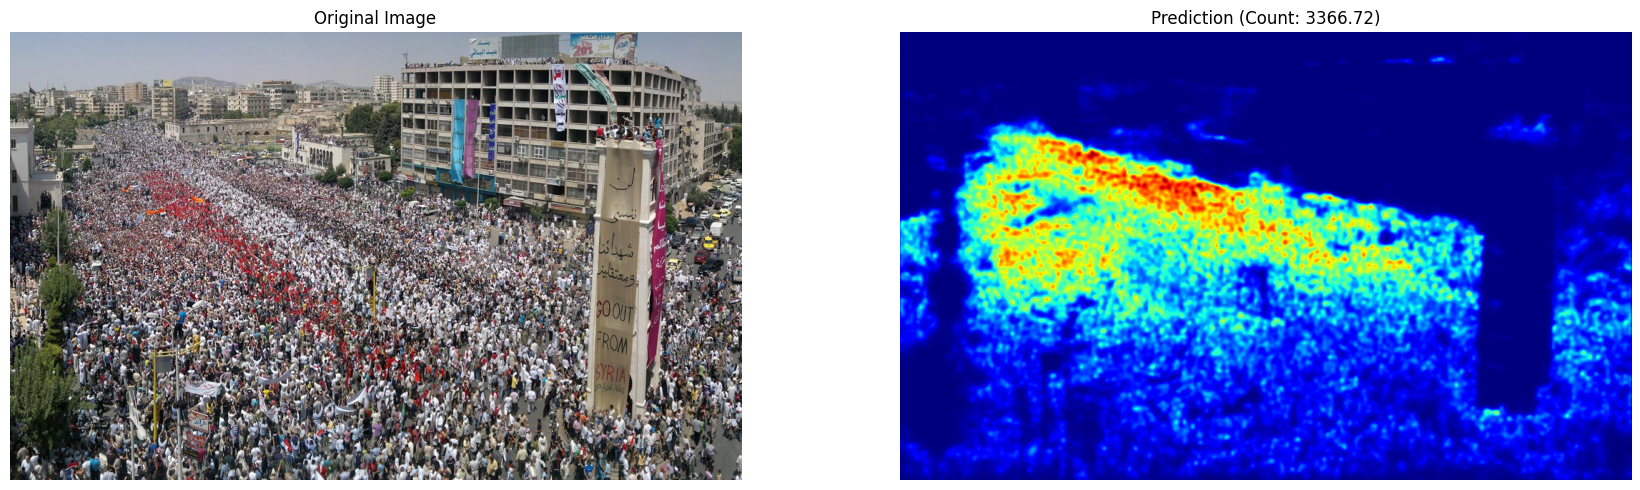

In [18]:
vis.visualize_sample(original_image, pred=result, cmap='jet')

In [11]:
vis.visualize_model_graph(model.model, sample=sample)

************
Feature extraction failed; returning model and environment to normal
*************
'Tensor' object has no attribute 'tl_tensor_label_raw'
